## Setup

In [1]:
import pandas as pd
import geopandas as gpd
import os
import matplotlib.pyplot as plt
import json
from shapely import wkb
print(os.getcwd())

from neo4j import GraphDatabase
import psycopg2
from shapely.geometry import Point
from dotenv import load_dotenv


import contextily as cx
import rasterio
from rasterio.plot import show as rioshow



/workspaces/business-opportunity-graph/notebooks


### Definitions

In [3]:
#from gemini

def get_degrees(tx, node_label: str = None, rel_type: str = None) -> dict[int, int]:
    # Construct the node pattern: (n) if node_label is None/empty, or (n:Label) otherwise
    node_pattern = f"(n{f':{node_label}' if node_label else ''})"

    # Construct the relationship pattern: -[]- if rel_type is None/empty, or -[:TYPE]- otherwise
    rel_pattern = f"-[r{f':{rel_type}' if rel_type else ''}]-"

    query = f"""
    MATCH {node_pattern}{rel_pattern}()
    RETURN elementId(n) as id, count(r) as degree
    """
    
    result = tx.run(query)
    # The result.data() method returns a list of dictionaries, 
    # e.g., [{'id': '4:0', 'degree': 5}, {'id': '4:1', 'degree': 3}]
    res = result.data()
    return res

In [ ]:
#functions from Graph Data Science with Neo4J by Estelle Scifo
# def get_degrees(tx, node_label: str, rel_type: str) -> dict[int, int]:
#     query = f"""
#     MATCH (n:{node_label})-[r:{rel_type}]-() 
#     RETURN elementId(n) as id, count(r) as degree
#     """
#     result = tx.run(query)
#     res = result.data()
#     return res







In [ ]:
SD_crs = 'EPSG:26946'
common_crs = "EPSG:4326"


data_path = '../data/'



In [ ]:
def read_node_json(filename: str) -> pd.DataFrame:
    """Read a JSON file into a pandas DataFrame."""
    df = pd.read_json(f"../data/nodes/{filename}")
    print(f"Data read from data/nodes/{filename}")
    return df

### Load Data

In [ ]:


boundaries_path ='/data/external/City_and_County_Boundaries.zip'
boundaries_gdf = gpd.read_file(boundaries_path)



communities_path = '/data/external/sd_community_boundaries.csv'
communities = gpd.read_file(communities_path)
communities_gdf = gpd.GeoDataFrame(
    geometry=gpd.GeoSeries.from_wkt(communities['geometry'], crs=common_crs), data=communities
)
communities_gdf = communities_gdf.rename(columns={'name': 'community'})



business_location_df = pd.read_json("../data/nodes/business_location.json")
business_location_geometry = [Point(xy) for xy in zip(business_location_df.longitude, business_location_df.latitude)]
business_location_gdf = gpd.GeoDataFrame(business_location_df, crs="EPSG:4326", geometry=business_location_geometry)
business_location_gdf = business_location_gdf[business_location_gdf['longitude']!=180] #fix these outliers


block_group_df = pd.read_json("../data/nodes/block_group.json")
block_group_geometry = gpd.GeoSeries.from_wkt(block_group_df['geom_wkt'])
block_group_gdf = gpd.GeoDataFrame(block_group_df, crs="EPSG:4326", geometry=block_group_geometry)




In [96]:
zipcode_df = pd.read_json("../data/nodes/zipcode.json")
zipcode_geometry = gpd.GeoSeries.from_wkt(zipcode_df['geom_wkt'])
zipcode_gdf = gpd.GeoDataFrame(zipcode_df, crs="EPSG:4326", geometry=zipcode_geometry)

In [ ]:
boundaries_gdf = boundaries_gdf.to_crs(common_crs)
communities_gdf = communities_gdf.to_crs(common_crs)



In [7]:
sd_boundaries_gdf = boundaries_gdf[boundaries_gdf['COUNTY_NAM'] == 'San Diego']
sd_boundaries_mixed = sd_boundaries_gdf[['CITY','geometry']]

sd_cities_boundaries_gdf= sd_boundaries_mixed.rename(columns={"CITY": "City"}).dissolve(by= 'City').reset_index()


In [8]:
business_location_gdf[business_location_gdf['franchise']=="FRANCHISE"].head()

,id,name,url,address,city,zip,latitude,longitude,blockgroup,categories,avg_rating,franchise,confidence,reasoning,geom,geom_ewkt,geometry
1,24,Wetzel's Pretzels,https://www.google.com/maps/place//data=!4m2!3...,"Wetzel's Pretzels, 869 W. Harbor Drive, #C2-F,...",San Diego,92101,32.708565,-117.170277,54023.0,[Pretzel store],3.9,FRANCHISE,0.95,Wetzel's Pretzels is a well-known chain specia...,0101000020E6100000DD0F2ED3E54A5DC0B68AB443B25A...,SRID=4326;POINT(-117.1702774 32.7085652),POINT (-117.17028 32.70857)
3,49,Brainy Actz Escape Rooms San Diego,https://www.google.com/maps/place//data=!4m2!3...,"Brainy Actz Escape Rooms San Diego, 10211 Paci...",San Diego,92121,32.903380,-117.190299,83462.0,"[Escape room center, Children's amusement cent...",4.3,FRANCHISE,0.85,The name 'Brainy Actz Escape Rooms' suggests a...,0101000020E6100000BEFD6FDB2D4C5DC08F2EDBF3A173...,SRID=4326;POINT(-117.1902989 32.9033799),POINT (-117.1903 32.90338)
4,50,Einstein Bros. Bagels,https://www.google.com/maps/place//data=!4m2!3...,"Einstein Bros. Bagels, 911 Lomas Santa Fe Dr, ...",Solana Beach,92075,32.994224,-117.255235,173061.0,"[Bagel shop, Bakery, Breakfast restaurant, Caf...",3.9,FRANCHISE,0.95,Einstein Bros. Bagels is a well-known chain wi...,0101000020E61000007A53ECC355505DC0BAB1EABD427F...,SRID=4326;POINT(-117.2552347 32.9942243),POINT (-117.25523 32.99422)
14,253,Subway,https://www.google.com/maps/place//data=!4m2!3...,"Subway, 1915 El Cajon Blvd, San Diego, CA 92104",San Diego,92104,32.754837,-117.144664,9023.0,"[Sandwich shop, Caterer, Fast food restaurant,...",4.2,FRANCHISE,1.00,Subway is a well-known franchise brand recogni...,0101000020E610000084590D2E42495DC0F0E65F819E60...,SRID=4326;POINT(-117.1446643 32.7548372),POINT (-117.14466 32.75484)
16,289,Chevron,https://www.google.com/maps/place//data=!4m2!3...,"Chevron, 604 Dennery Rd, San Diego, CA 92154",San Diego,92154,32.583267,-117.032714,100172.0,"[Gas station, Auto repair shop, Convenience st...",2.6,FRANCHISE,0.90,Chevron is a well-known brand and operates as ...,0101000020E6100000C40776FC17425DC003EB387EA84A...,SRID=4326;POINT(-117.032714 32.583267),POINT (-117.03271 32.58327)


In [ ]:
state_df = read_node_json("state.json")
county_df = read_node_json("county.json")
city_df = read_node_json("city.json")
zipcode_df = read_node_json("zipcode.json")
community_df = read_node_json("community.json")
blockgroup_df = read_node_json("block_group.json")
brand_df = read_node_json("brand.json")
business_location_df = read_node_json("business_location.json")
zone_location_df = read_node_json("zone_location.json")
zone_type_df = read_node_json("zone_type.json")


Data read from data/nodes/state.json
Data read from data/nodes/county.json
Data read from data/nodes/city.json
Data read from data/nodes/zipcode.json
Data read from data/nodes/community.json
Data read from data/nodes/block_group.json
Data read from data/nodes/brand.json
Data read from data/nodes/business_location.json
Data read from data/nodes/zone_location.json
Data read from data/nodes/zone_type.json


In [10]:
zone_location_df.describe()

,id,imp_date,shape_length,shape_area
count,3677.000000,3.677000e+03,3677.000000,3.677000e+03
mean,1839.000000,1.283777e+12,6371.246213,2.446850e+06
std,1061.602798,2.027504e+11,16695.839735,1.883789e+07
min,1.000000,1.084320e+12,2.384195,1.096053e-02
25%,920.000000,1.141085e+12,1518.738798,9.238434e+04
50%,1839.000000,1.141085e+12,3116.274208,3.594703e+05
75%,2758.000000,1.483142e+12,6066.610533,1.142353e+06
max,3677.000000,1.733011e+12,488287.762815,7.040379e+08


<Axes: >

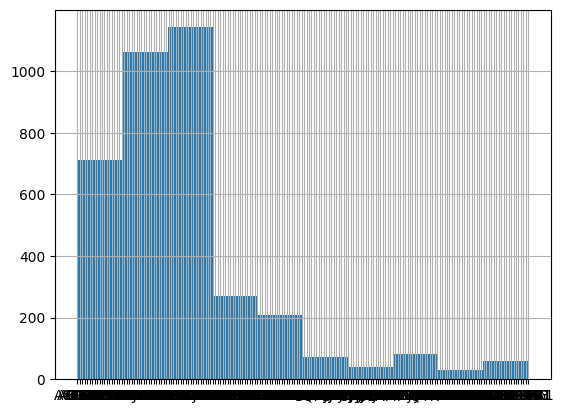

In [40]:
zone_location_df['zone_name'].hist()

### Connect to neo4j

In [6]:

load_dotenv("../.env")

class Config:
    def __init__(self, mode="LOCAL", DATABASE='neo4j'):
        mode = mode.upper()

        if mode == "LOCAL":
            self.URI = os.getenv("NEO4J_URI_LOCAL")
            self.USER = os.getenv("NEO4J_USER_LOCAL")
            self.PASSWORD = os.getenv("NEO4J_PASSWORD_LOCAL")
        elif mode == "GROUP":
            self.URI = os.getenv("NEO4J_GROUP_URI")
            self.USER = os.getenv("NEO4J_GROUP_USER")
            self.PASSWORD = os.getenv("NEO4J_GROUP_PASSWORD")
        else:
            raise ValueError("Mode must be 'LOCAL' or 'GROUP'.")
        self.DATABASE = DATABASE


config = Config(mode="LOCAL",DATABASE = "dse203test")
driver = GraphDatabase.driver(config.URI, auth=(config.USER, config.PASSWORD))

with driver.session(database=config.DATABASE) as session:
    session.run("MATCH (n) RETURN n LIMIT 1")
    print(f"Connection successful")

def query_neo4j(cypher_query: str, parameters: dict = None):
    with driver.session(database=config.DATABASE) as session:
        result = session.run(cypher_query, parameters)
        return result.data()

Connection successful


## Visualizations

### Graph Degree Distribution

In [7]:
def plot_degree_distribution(degrees: pd.Series, log_mode: bool = True, label = ""):
    # define figure and subplots
    fig = plt.figure(figsize=(12, 8))
    ax1 = fig.subplots(1, 1)

    # compute and draw degree distribution
    distribution = degrees.value_counts().sort_index()
    distribution.plot(
        ax=ax1, 
        marker="o", color="k",
        title=f"Degree Distribution: {label}", xlabel="Degree", ylabel="nbOccurrences",
        logy=log_mode, 
        logx=log_mode
    )

    fig.tight_layout()
    return fig

[{'id': '4:94cd433c-2a2c-4c22-9feb-82791caf0942:34095', 'degree': 2}, {'id': '4:94cd433c-2a2c-4c22-9feb-82791caf0942:34096', 'degree': 3}, {'id': '4:94cd433c-2a2c-4c22-9feb-82791caf0942:34097', 'degree': 3}]


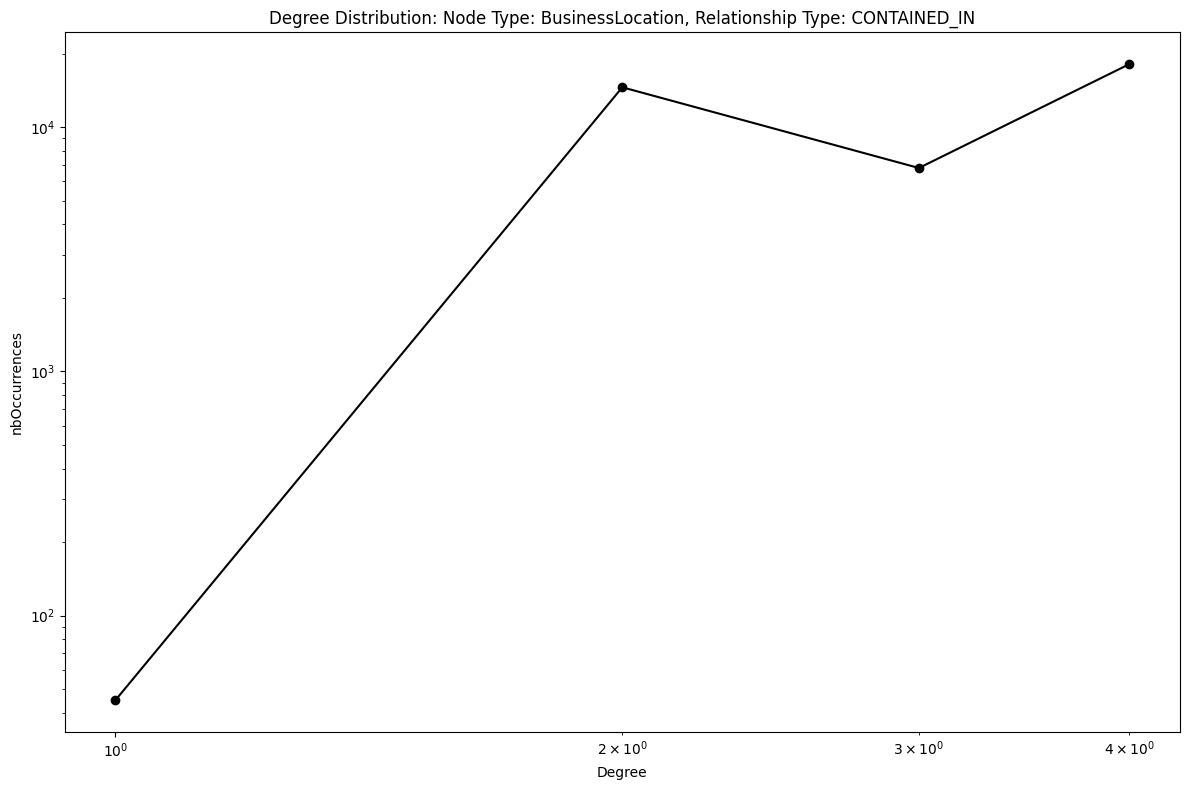

In [15]:
node_type = 'BusinessLocation'
relatiionship_type = 'CONTAINED_IN'


if node_type == 'Any':
    nt = ""
elif node_type == 'All':
    nt = ""

else:
    nt = node_type

if relatiionship_type == 'Any':
    rt = ""
elif relatiionship_type == 'All':
    rt = ""

else:
    rt = relatiionship_type

with driver.session(database=config.DATABASE) as s:
    # degree_data = s.execute_read(get_degrees, "BusinessLocation", "contained_in")
    degree_data = s.execute_read(get_degrees, nt, rt)    
print(degree_data[:3])


data = pd.DataFrame(degree_data)
plot_degree_distribution(data.degree, label= f'Node Type: {node_type}, Relationship Type: {relatiionship_type}');

In [20]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Define the Cypher Query
# This counts every relationship edge grouped by the types of nodes it connects
query = """
MATCH (n)-[r*2..2]-(m)
RETURN labels(n)[0] AS Source, labels(m)[0] AS Target, count(r) AS Weight
ORDER BY Source, Target
"""

# 2. Execute Query
with driver.session(database=config.DATABASE) as session:
    result = session.run(query)
    data = [record.data() for record in result]

# 3. Process Data
df = pd.DataFrame(data)

# Create the Matrix (Pivot Table)
# Rows = Source Node, Columns = Target Node, Values = Number of Connections
mixing_matrix = df.pivot(index="Source", columns="Target", values="Weight")
mixing_matrix = mixing_matrix.fillna(0) # Zero implies no direct relationship exists

# 4. Plot Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(mixing_matrix, annot=True, fmt='g', cmap='Reds', linewidths=.5)

plt.title('Schema Mixing Matrix: Node Connectivity Density')
plt.ylabel('Source Node')
plt.xlabel('Target Node')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

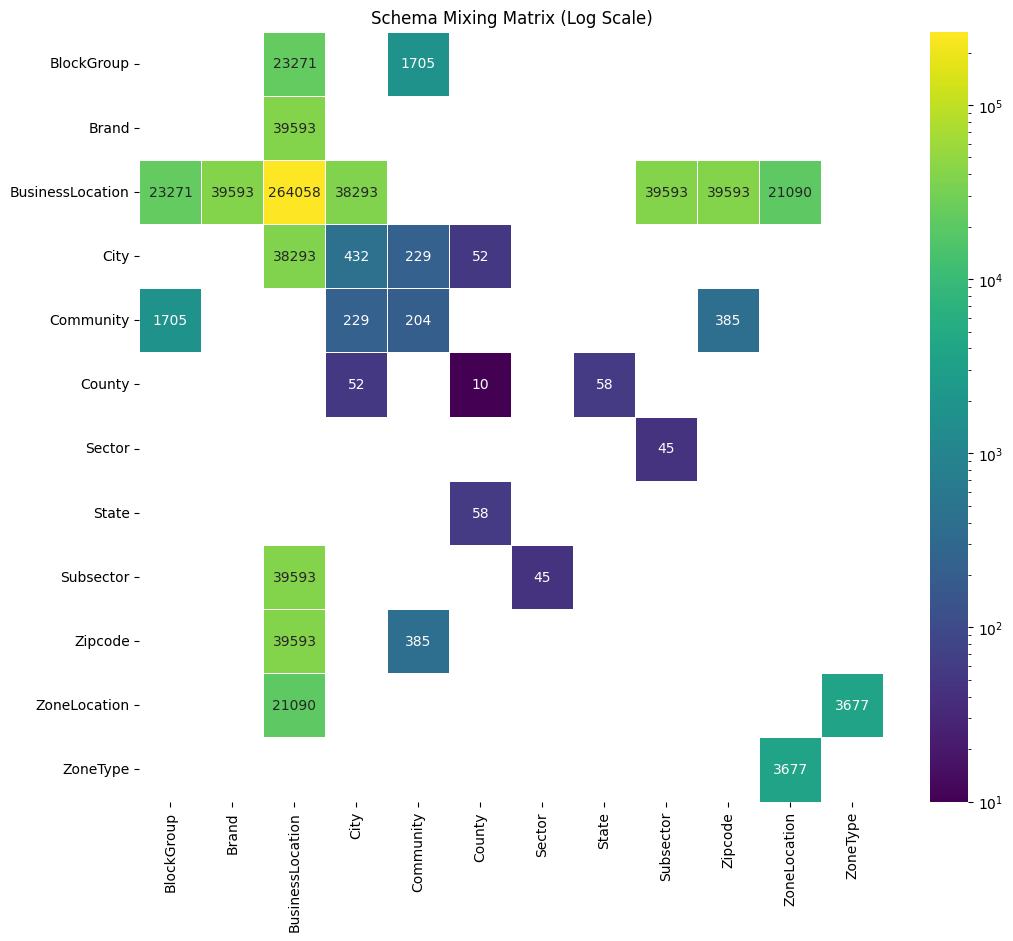

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
import pandas as pd
# 1. Pivot the Data
nodes = sorted(list(set(df['Source']).union(set(df['Target']))))
matrix = pd.DataFrame(0, index=nodes, columns=nodes)
for _, row in df.iterrows():
    matrix.loc[row['Source'], row['Target']] = row['Weight']

# 2. Create Annotations (Hide Zeros)
annot_labels = matrix.applymap(lambda x: str(x) if x > 0 else "")

# 3. Plot with LogNorm
plt.figure(figsize=(12, 10))
sns.heatmap(matrix, 
            annot=annot_labels, 
            fmt='', 
            norm=LogNorm(),     # <--- The key fix
            cmap='viridis',     # <--- A high-contrast colormap
            linewidths=.5,
            mask=(matrix==0))   # <--- Hides the zeros

plt.title('Schema Mixing Matrix (Log Scale)')
plt.show()

### Maps

In [11]:
boundaries_zip = 'City_and_County_Boundaries.zip'
boundaries_path = os.path.join(data_path, boundaries_zip)
boundaries_gdf = gpd.read_file(boundaries_path)


boundaries_gdf = boundaries_gdf.to_crs(common_crs)

sd_boundaries_gdf = boundaries_gdf[boundaries_gdf['COUNTY_NAM'] == 'San Diego']
sd_county_geom = sd_boundaries_gdf.geometry.union_all()
sd_county_gdf = gpd.GeoDataFrame(
    geometry=[sd_county_geom], 
    crs=sd_boundaries_gdf.crs
)

sd_county_gdf['name'] = "San Diego County"


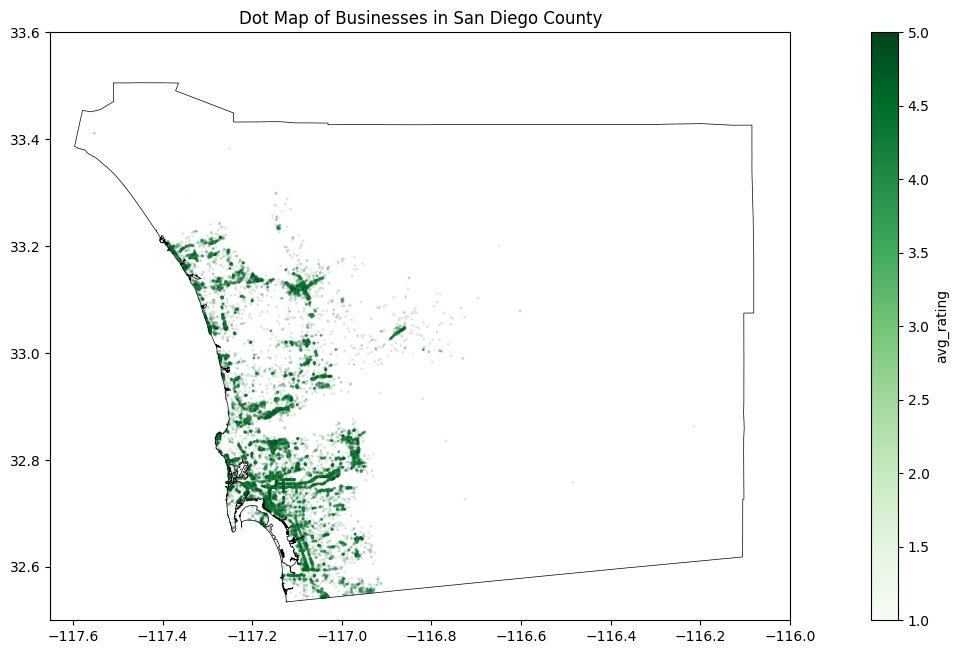

In [21]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig1, ax = plt.subplots(figsize=(10, 10))

# create a colorbar axes whose height will match `ax`
divider = make_axes_locatable(ax)
# size controls width of colorbar (e.g. "3%"), pad controls gap
cax = divider.append_axes("right", size="3%", pad=0.1)


bus_loc_plot = business_location_gdf.plot(ax=ax,
                                        cax = cax,
                                          column='avg_rating',
                                          markersize=1, 
                                          legend =True, legend_kwds={'label': 'avg_rating'},
                                          alpha=0.1,
                                          cmap = 'Greens')# color='purple'

sd_county_gdf.plot(color = 'none', 
                     ax=ax, 
                     edgecolor='black',
                     linewidth=0.5)#, norm=norm)

ax.set_title('Dot Map of Businesses in San Diego County')


bus_loc_plot.set_xlim(-117.65,-116.0)
bus_loc_plot.set_ylim(32.5,33.6)
plt.tight_layout()
plt.show()


/tmp/ipykernel_5907/3823156379.py:12: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(communities_gdf.geometry.centroid.x,
/tmp/ipykernel_5907/3823156379.py:13: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  communities_gdf.geometry.centroid.y,


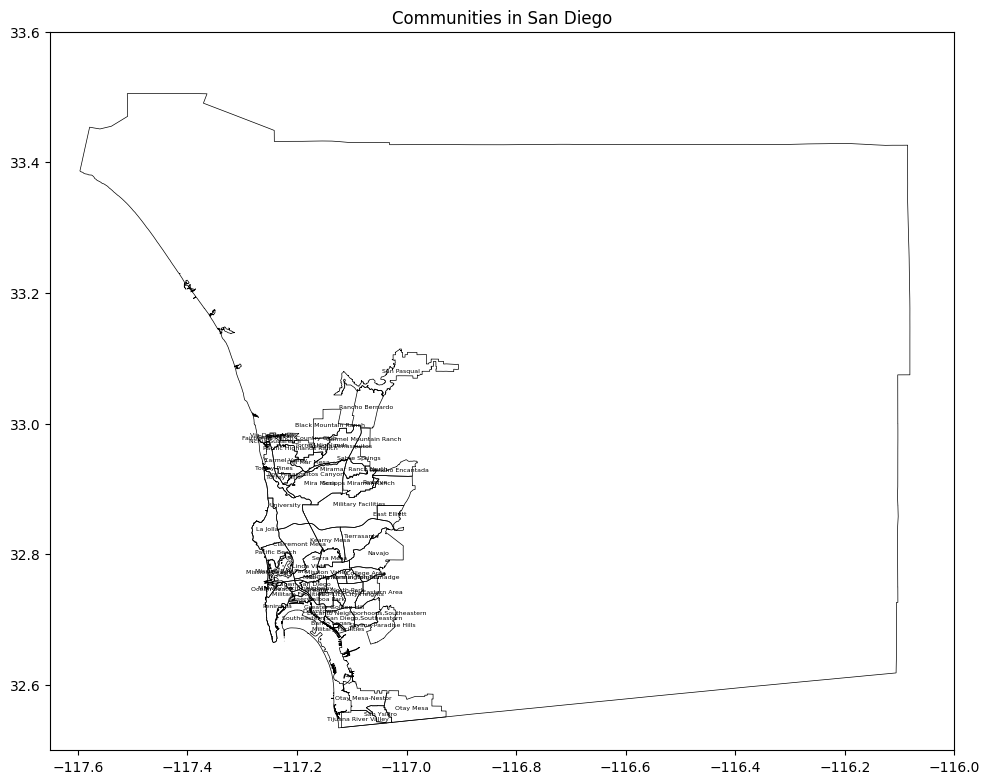

In [26]:
fig1, ax = plt.subplots(figsize=(10, 10))

bus_loc_plot = communities_gdf.plot(color = 'none', 
                     ax=ax, 
                     edgecolor='black',
                     linewidth=0.5)#, norm=norm)

bus_loc_plot.set_xlim(-117.4,-116.9)
bus_loc_plot.set_ylim(32.5,33.3)


for x, y, label in zip(communities_gdf.geometry.centroid.x,
                      communities_gdf.geometry.centroid.y,
                      communities_gdf['community']):

        ax.text(x, y, label, fontsize=4.5, ha='center', va='center')


sd_county_gdf.plot(color = 'none', 
                     ax=ax, 
                     edgecolor='black',
                     linewidth=0.5)#, norm=norm)

ax.set_title('Communities in San Diego')


bus_loc_plot.set_xlim(-117.65,-116.0)
bus_loc_plot.set_ylim(32.5,33.6)
plt.tight_layout()
plt.show()



In [48]:
print(communities_gdf['community'].values)

['Southeastern San Diego,Southeastern' 'Military Facilities'
 'Otay Mesa-Nestor' 'Otay Mesa' 'San Ysidro' 'Tijuana River Valley'
 'Mission Valley' 'Old Town San Diego' 'Midway-Pacific Highway'
 'Mid-City:City Heights' 'Encanto Neighborhoods,Southeastern'
 'Skyline-Paradise Hills' 'Rancho Bernardo' 'Mira Mesa' 'Uptown'
 'Tierrasanta' 'Torrey Hills' 'Serra Mesa' 'Military Facilities'
 'Barrio Logan' 'San Pasqual' 'Rancho Penasquitos'
 'Los Penasquitos Canyon' 'Carmel Valley' 'Kearny Mesa' 'Linda Vista'
 'Mid-City:Kensington-Talmadge' 'Mid-City:Normal Heights'
 'Greater North Park' 'Military Facilities' 'Balboa Park' 'Reserve'
 'Downtown' 'Torrey Pines' 'Torrey Highlands' 'Pacific Highlands Ranch'
 'Del Mar Mesa' 'Rancho Encantada' 'Scripps Miramar Ranch' 'University'
 'Reserve' 'Greater Golden Hill' 'Black Mountain Ranch'
 'Carmel Mountain Ranch' 'Via De La Valle' 'Fairbanks Ranch Country Club'
 'Reserve' 'Ncfua Subarea Ii' 'Reserve' 'Reserve' 'La Jolla'
 'East Elliott' 'Miramar Ranch No

In [52]:
intersect_both_list = list(set(community_df ['name'] .tolist()) & set( communities_gdf['community'].values.tolist()))
print(intersect_both_list)


['Ocean Beach', 'Rancho Penasquitos', 'Black Mountain Ranch', 'Otay Mesa', 'Carmel Valley', 'La Jolla', 'Mission Bay Park', 'Rancho Bernardo', 'Torrey Pines', 'Pacific Beach', 'Balboa Park', 'Mission Beach', 'Tijuana River Valley', 'Barrio Logan', 'Tierrasanta', 'Torrey Highlands', 'Mira Mesa', 'Linda Vista', 'Serra Mesa', 'Sabre Springs', 'San Ysidro', 'Kearny Mesa', 'San Pasqual', 'Miramar Ranch North']


In [ ]:
bg.ctblockgroup
85071
85091
85103
93061
95021
95022
95112
83451
85051
85111
85112
85113
92011
93013
93064
94001
95102

In [ ]:

# bg_list = [85071, 85091, 85103, 93061, 95021, 95022, 95112, 83451, 85051, 85111, 85112, 85113, 92011, 93013, 93064, 94001, 95102]


In [62]:
sd_city = 'San Diego'
sd_boundaries_gdf = boundaries_gdf[boundaries_gdf['CITY'] == sd_city]
sd_city_boundaries_gdf = sd_boundaries_gdf.rename(columns={"CITY": "City"}).dissolve(by= 'City').reset_index()

/tmp/ipykernel_5907/4011815397.py:56: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(shared_communities.geometry.centroid.x,
/tmp/ipykernel_5907/4011815397.py:57: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  shared_communities.geometry.centroid.y,
/tmp/ipykernel_5907/4011815397.py:77: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(shared_zip_gdf.geometry.centroid.x,
/tmp/ipykernel_5907/4011815397.py:78: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-pr

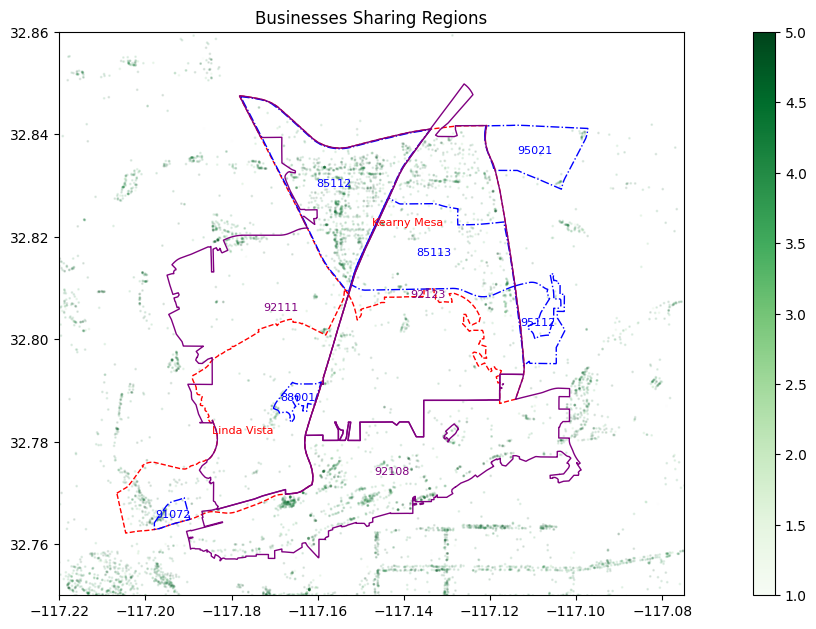

In [112]:
bg_list = [   85112, 85113,95112 ,  88001, 91072,95021]
shared_bg_gdf = block_group_gdf[block_group_gdf['ctblockgroup'].isin(bg_list)]
zip_list = [92111, 92123, 92108]
shared_zip_gdf = zipcode_gdf[zipcode_gdf['zipcode'].isin(zip_list)]


communities_list = ['Linda Vista', 'Kearny Mesa']
shared_communities = communities_gdf[communities_gdf['community'].isin(communities_list)]
fig1, ax = plt.subplots(figsize=(10, 10))

# create a colorbar axes whose height will match `ax`
divider = make_axes_locatable(ax)
# size controls width of colorbar (e.g. "3%"), pad controls gap
cax = divider.append_axes("right", size="3%", pad=0.1)



bus_shared_plot = business_location_gdf.plot(ax=ax,cax=cax,
                                          column='avg_rating',
                                          markersize=1, 
                                          legend =True, 
                                          alpha=0.1,
                                          cmap = 'Greens')# color='purple'


shared_communities.plot(color = 'none', 
                     ax=ax, 
                     edgecolor='red',
                     linewidth=1,
                     linestyle='--'
                     )#, norm=norm)


shared_bg_gdf.plot(color = 'none',
                         ax=ax, 
                         edgecolor='blue',
                         linewidth=1,
                         linestyle='-.'
                         )

# sd_city_boundaries_gdf.plot(color = 'none',
#                          ax=ax, 
#                          edgecolor='black',
#                          linewidth=2.5)#, norm=norm)    


shared_zip_gdf.plot(color = 'none',
                                ax=ax,
                                edgecolor='purple',
                                linewidth=1)

bus_shared_plot.set_xlim(-117.22,-117.075)
bus_shared_plot.set_ylim(32.75,32.86)


for x, y, label in zip(shared_communities.geometry.centroid.x,
                      shared_communities.geometry.centroid.y,
                      shared_communities['community']):

        ax.text(x, y, label, fontsize=8, ha='center', va='center', color='red')


# for x, y, label in zip(sd_city_boundaries_gdf.geometry.centroid.x,
#                       sd_city_boundaries_gdf.geometry.centroid.y,
#                       sd_city_boundaries_gdf['City']):

#         ax.text(x, y, label, fontsize=8, ha='center', va='center')

# block_group_sample_gdf = block_group_gdf.sample(frac=0.15, random_state=3)

# for x, y, label in zip(block_group_sample_gdf.geometry.centroid.x,
#                       block_group_sample_gdf.geometry.centroid.y,
#                       block_group_sample_gdf['ctblockgroup']):
#         ax.text(x, y, label, fontsize=8, ha='center', va='center')


for x, y, label in zip(shared_zip_gdf.geometry.centroid.x,
                      shared_zip_gdf.geometry.centroid.y,
                      shared_zip_gdf['zipcode']):
        ax.text(x, y, label, fontsize=8, ha='center', va='center', color='purple')





for x, y, label in zip(shared_bg_gdf.geometry.centroid.x,
                      shared_bg_gdf.geometry.centroid.y,
                      shared_bg_gdf['ctblockgroup']):

        ax.text(x, y, label, fontsize=8, ha='center', va='center', color='blue')
ax.set_title('Businesses Sharing Regions')


plt.show()


/tmp/ipykernel_149/2946580479.py:20: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(communities_gdf.geometry.centroid.x,
/tmp/ipykernel_149/2946580479.py:21: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  communities_gdf.geometry.centroid.y,


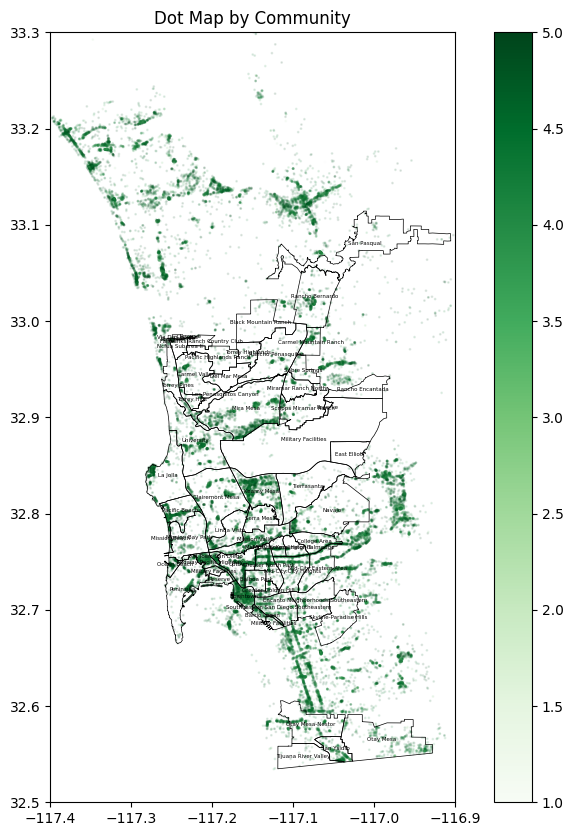

In [33]:
fig1, ax = plt.subplots(figsize=(10, 10))

bus_loc_plot = business_location_gdf.plot(ax=ax,
                                          column='avg_rating',
                                          markersize=1, 
                                          legend =True, 
                                          alpha=0.1,
                                          cmap = 'Greens')# color='purple'


communities_gdf.plot(color = 'none', 
                     ax=ax, 
                     edgecolor='black',
                     linewidth=0.5)#, norm=norm)

bus_loc_plot.set_xlim(-117.4,-116.9)
bus_loc_plot.set_ylim(32.5,33.3)


for x, y, label in zip(communities_gdf.geometry.centroid.x,
                      communities_gdf.geometry.centroid.y,
                      communities_gdf['community']):

        ax.text(x, y, label, fontsize=4, ha='center', va='center')

ax.set_title('Business Dot Map by Community')

plt.show()



/tmp/ipykernel_149/610509852.py:25: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(sd_cities_boundaries_gdf.geometry.centroid.x,
/tmp/ipykernel_149/610509852.py:26: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  sd_cities_boundaries_gdf.geometry.centroid.y,


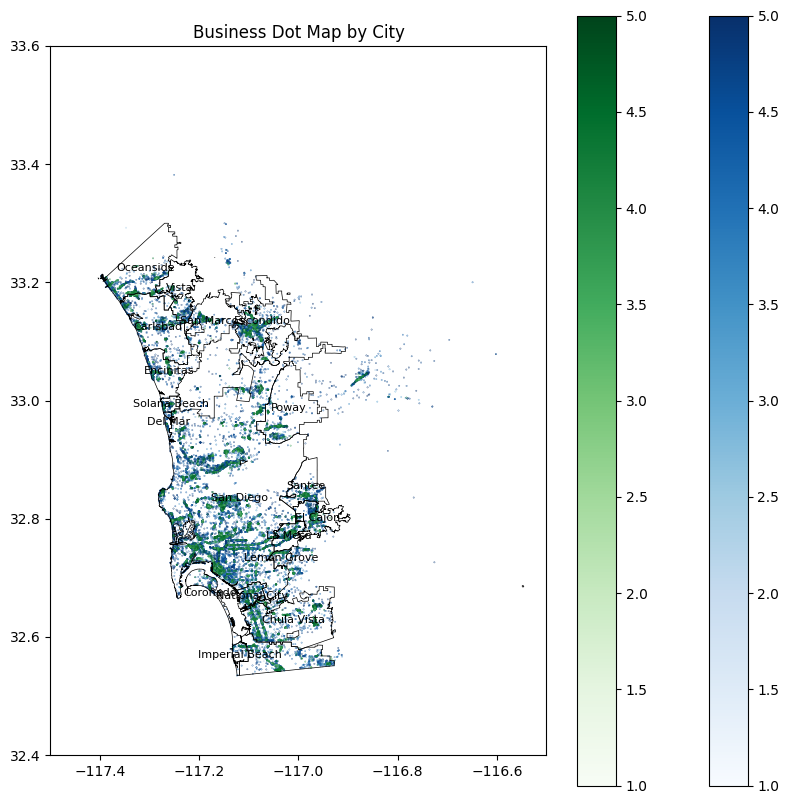

In [34]:
fig2, ax2 = plt.subplots(figsize=(10, 10))
# bus_loc_cities_plot = business_location_gdf.plot(ax=ax2, color='purple',markersize=1, alpha=0.1)

bus_loc_cities_plot = business_location_gdf[business_location_gdf['franchise']=="INDEPENDENT"].plot(ax=ax2,
                                          column='avg_rating',
                                          markersize=0.05, 
                                          legend =True, 
                                          alpha=1,
                                          cmap = 'Blues')# color='purple'

business_location_gdf[business_location_gdf['franchise']=="FRANCHISE"].plot(ax=ax2,
                                          column='avg_rating',
                                          markersize=0.05, 
                                          legend =True, 
                                          alpha=1,
                                          cmap = 'Greens')# color='purple'


sd_cities_boundaries_gdf.plot(color = 'none', ax=ax2, edgecolor='black', linewidth=0.5)#, norm=norm)

bus_loc_cities_plot.set_xlim(-117.5,-116.5)
bus_loc_cities_plot.set_ylim(32.4,33.6)


for x, y, label in zip(sd_cities_boundaries_gdf.geometry.centroid.x,
                      sd_cities_boundaries_gdf.geometry.centroid.y,
                      sd_cities_boundaries_gdf['City']):

        ax2.text(x, y, label, fontsize=8, ha='center', va='center')

ax2.set_title('Business Dot Map by City')

plt.show()



In [49]:
block_group_gdf.dropna(axis=1).describe()

,ctblockgroup,medhinc_cy,avghinc_cy,gini_fy,indmanu_cy,totpop_cy,fem25,fem30,fem35,male25,...,crmcytotc,di100_cy,di150_cy,countyfp,tractce,population,apportionm,blkgrpce,ogc_fid,statefp
count,2085.000000,2085.000000,2085.000000,2085.000000,2085.000000,2085.000000,2085.000000,2085.000000,2085.000000,2085.000000,...,2085.000000,2085.000000,2085.000000,2085.000000,2085.000000,2.085000e+03,2085.000,2085.000000,2085.000000,2085.0
mean,126022.392806,100628.615348,132083.483933,31.424604,75.781295,1614.615348,60.197122,63.650839,55.697362,65.170264,...,99.938129,130.030216,44.665707,72.355396,12602.033573,2.191000e+00,2.576,2.057074,1027.160192,6.0
std,60023.031904,42435.403584,57229.045532,7.596515,68.343557,1094.450412,55.467080,43.311618,33.515960,97.740089,...,70.338021,83.489242,46.960953,5.526313,6002.307700,4.441957e-16,0.000,1.023760,590.159224,0.0
min,1001.000000,0.000000,0.000000,0.000000,0.000000,14.000000,2.000000,2.000000,0.000000,1.000000,...,5.000000,0.000000,0.000000,25.000000,100.000000,2.191000e+00,2.576,1.000000,1.000000,6.0
25%,83504.000000,66989.000000,89399.000000,26.100000,29.000000,1090.000000,33.000000,37.000000,35.000000,34.000000,...,47.000000,74.000000,12.000000,73.000000,8350.000000,2.191000e+00,2.576,1.000000,522.000000,6.0
50%,133223.000000,98573.000000,122558.000000,30.900000,59.000000,1468.000000,52.000000,57.000000,50.000000,54.000000,...,83.000000,115.000000,31.000000,73.000000,13322.000000,2.191000e+00,2.576,2.000000,1015.000000,6.0
75%,178014.000000,124728.000000,164230.000000,36.200000,102.000000,1965.000000,78.000000,82.000000,70.000000,82.000000,...,138.000000,173.000000,64.000000,73.000000,17801.000000,2.191000e+00,2.576,3.000000,1536.000000,6.0
max,221024.000000,200001.000000,422158.000000,63.200000,619.000000,37603.000000,1949.000000,1097.000000,599.000000,3906.000000,...,588.000000,969.000000,499.000000,73.000000,22102.000000,2.191000e+00,2.576,7.000000,2057.000000,6.0


/tmp/ipykernel_5907/2697014919.py:23: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(block_group_sample_gdf.geometry.centroid.x,
/tmp/ipykernel_5907/2697014919.py:24: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  block_group_sample_gdf.geometry.centroid.y,
/tmp/ipykernel_5907/2697014919.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(sd_cities_boundaries_gdf.geometry.centroid.x,
/tmp/ipykernel_5907/2697014919.py:31: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.

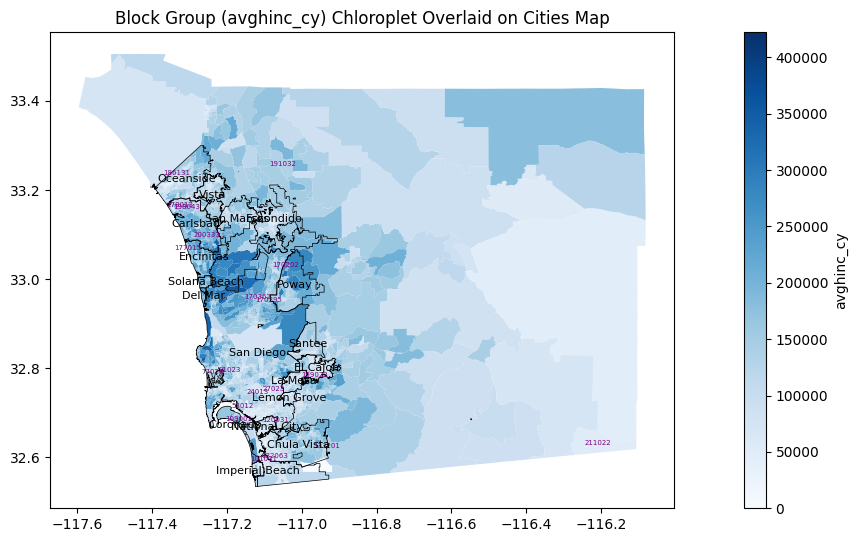

In [113]:


fig3, ax3 = plt.subplots(figsize=(10, 10))
# create a colorbar axes whose height will match `ax`
divider = make_axes_locatable(ax3)
# size controls width of colorbar (e.g. "3%"), pad controls gap
cax3 = divider.append_axes("right", size="3%", pad=0.1)


bg_plot_var = 'avghinc_cy'# 'n37_sales'
blockgroup_cities_plot = block_group_gdf.plot(ax=ax3, cax = cax3,

                                          column=bg_plot_var,
                                          markersize=0.05, 
                                          legend =True, legend_kwds={'label': bg_plot_var},
                                          alpha=1,
                                          cmap = 'Blues')# color='purple'



sd_cities_boundaries_gdf.plot(color = 'none', ax=ax3, edgecolor='black', linewidth=0.5)#, norm=norm)

#use a sample to add the block group names since there are so many
block_group_sample_gdf = block_group_gdf.sample(frac=0.01, random_state=42)
for x, y, label in zip(block_group_sample_gdf.geometry.centroid.x,
                      block_group_sample_gdf.geometry.centroid.y,
                      block_group_sample_gdf['ctblockgroup']):

        ax3.text(x, y, label, fontsize=5, ha='center', va='center', color='purple')


for x, y, label in zip(sd_cities_boundaries_gdf.geometry.centroid.x,
                      sd_cities_boundaries_gdf.geometry.centroid.y,
                      sd_cities_boundaries_gdf['City']):

        ax3.text(x, y, label, fontsize=8, ha='center', va='center')

ax3.set_title(f'Block Group ({bg_plot_var}) Chloroplet Overlaid on Cities Map')

plt.show()


/tmp/ipykernel_149/565071665.py:28: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(sd_cities_boundaries_gdf.geometry.centroid.x,
/tmp/ipykernel_149/565071665.py:29: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  sd_cities_boundaries_gdf.geometry.centroid.y,


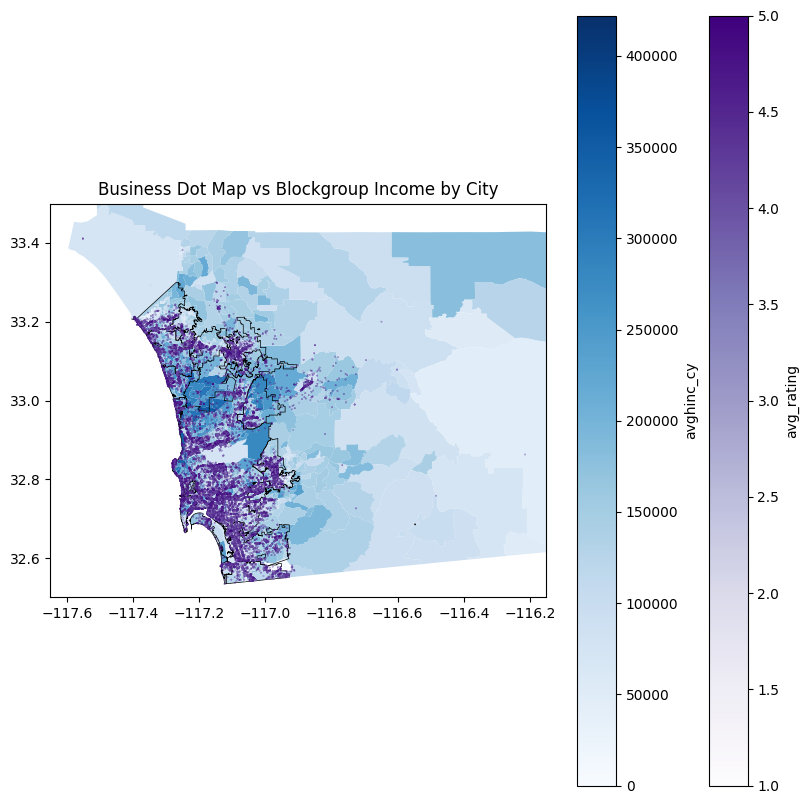

In [77]:
fig4, ax4 = plt.subplots(figsize=(10, 10))
# bus_loc_cities_plot = business_location_gdf.plot(ax=ax2, color='purple',markersize=1, alpha=0.1)

bus_plot_var = 'avg_rating'
bus_bg_cities_plot = business_location_gdf.sample(frac=1,random_state=42).plot(ax=ax4,
                                          column=bus_plot_var,
                                          markersize=0.05, 
                                          legend =True, legend_kwds={'label': bus_plot_var},
                                          alpha=1,
                                          cmap = 'Purples',zorder= 10)# color='purple'



bg_plot_var = 'avghinc_cy'# 'n37_sales'
blockgroup_cities_plot = block_group_gdf.plot(ax=ax4,
                                          column=bg_plot_var,
                                          markersize=0.05, 
                                          legend =True, legend_kwds={'label': bg_plot_var},
                                          alpha=1,
                                          cmap = 'Blues')# color='purple'

sd_cities_boundaries_gdf.plot(color = 'none', ax=ax4, edgecolor='black', linewidth=0.5)#, norm=norm)

bus_bg_cities_plot.set_xlim(-117.65,-116.15)
bus_bg_cities_plot.set_ylim(32.5,33.5)


for x, y, label in zip(sd_cities_boundaries_gdf.geometry.centroid.x,
                      sd_cities_boundaries_gdf.geometry.centroid.y,
                      sd_cities_boundaries_gdf['City']):

        ax2.text(x, y, label, fontsize=8, ha='center', va='center')

ax4.set_title('Business Dot Map vs Blockgroup Income by City')

plt.show()



Ignore below for now. WIP. Adding elevation

In [4]:
!pip install contextily 

Defaulting to user installation because normal site-packages is not writeable
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [2 lines of output]
      INFO:root:Building on Windows requires extra options to setup.py to locate needed GDAL files. More information is available in the README.
      ERROR: A GDAL API version must be specified. Provide a path to gdal-config using a GDAL_CONFIG environment variable or use a GDAL_VERSION environment variable.
      [end of output]
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
ERROR: Failed to build 'rasterio' when getting requirements to build wheel


ModuleNotFoundError: No module named 'contextily'

In [ ]:
elevation_filename = "nasadem_sd.tif"
elevation_path = os.path.join(data_path, elevation_filename)


f, ax = plt.subplots(1, figsize=(9, 9))
r = rasterio.open(elevation_path)
rioshow(r, zorder=1, alpha=0.75, ax=ax)
cx.add_basemap(ax, alpha=0.5, crs=r.crs)